# Investigate the number of observed events

In [1]:
# set working directory to project folder
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import plotly.io as pio
pio.renderers.default = "browser" 

import altair as alt
from itertools import combinations
import numpy as np
import math
import pypangraph as pp
from Bio import Phylo, SeqIO, AlignIO
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord

import random
import plotly.graph_objects as go
import plotly.express as px

import scipy.cluster.hierarchy as sch
from collections import defaultdict, deque, Counter
from Bio import Phylo

from pathlib import Path
import subprocess

from Bio.Phylo.TreeConstruction import DistanceCalculator
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

from junction_analysis.helpers import get_tree_order, cluster_by_tree, strip_newick_suffixes, write_shared_nodes_fasta, simplify_cluster_keys, count_trna_per_junction, get_core_alignment_lengths, core_block_snp_gaps, add_silhouette_scores, read_gff3_annotations
from junction_analysis.junction_trees import build_tree_from_block_list, compute_pairwise_distances, cluster_tree_by_branch_length
import junction_analysis.pangraph_utils as pu
from junction_analysis.plotting import plot_junction_pangraph_interactive, plot_block_distance_distribution, plot_pairwise_distance_hist, plot_event_counts_distribution, plot_events_per_junction, plot_cluster_count_distribution, plot_event_length_distribution, plot_cluster_count_vs_diversity, plot_marginal_scatter, plot_clustering_threshold_sweep, plot_event_mge_heatmap, plot_event_mge_stacked_bar
from junction_analysis.consensus import find_consensus_paths, make_deduplicated_paths, consensus_paths_and_assignments, find_consensus_paths_core, cluster_map_to_dataframe, collect_all_pairwise_distances, save_consensus_cache, collect_all_branch_lengths, fitch_parsimony_steps_per_cluster
from junction_analysis.block_alignment import create_block_msas, summarize_block_msas, analyze_alignment, cluster_alignment, retrieve_cluster_assignments
from junction_analysis.annotate_insertions import get_insertions_deletions_from_consensus, write_insertions_fasta, summarize_deletions_consensus, load_all_deletions_summaries, summarize_inversions_consensus, summarize_translocations_consensus, write_insertions_fasta, load_all_insertions_summaries, load_all_inversions_summaries, load_all_translocations_summaries, combine_all_junctions_summaries, count_events_per_junction, deduplicate_events, annotate_events_with_mges

In [2]:
base_path = Path("../results/atb_lookup_0001")

_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

# summarize results
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
trna_counts_df = count_trna_per_junction(annotations_dir="../results/junction_annotations",
    category_bins=[-1, 0, 50, 300, float("inf")], category_labels=["0", "1–50", "50–300", ">300"],)
summaries = combine_all_junctions_summaries(str(base_path), save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path=f"{base_path}/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"{base_path}/event_counts_per_junction.csv")
#ji_df = pd.read_csv("../results/consensus_analysis/mean_diversity_per_junction.csv") 

jdf_trna = jdf.copy().merge(trna_counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                 
jdf_clusters = jdf_trna.merge(cluster_df[["junction_name", "n_clusters"]].set_index("junction_name"), left_on="edge", right_index=True, how="left")

jdf_all = jdf_clusters.merge(counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                                                                                                              
jdf_all[counts_df.columns.drop("junction_name")] = jdf_all[counts_df.columns.drop("junction_name")].fillna(0)

#jdf_all = jdf_all.merge(ji_df.set_index("junction_name"), left_on="edge", right_index = True, how="left")  

jdf_all.rename(columns={"edge": "junction_name"}, inplace=True)

# only continue with junctions that have at least 2 different paths, otherwise they are not junctions (could happen because of duplications to elsewhere or syntheny breaks) 
jdf_all = jdf_all[jdf_all["n_categories"] >= 2]
# for now don't filter out junctions with only very few isolates, but might generally make sense to do so

jdf_hotspot = jdf_all[jdf_all["n_categories"] > 2]
jdf_nonsingleton = jdf_all[jdf_all["singleton"] == False]
jdf_binary = jdf_all[jdf_all["n_categories"] == 2]
jdf_singleton = jdf_binary[jdf_binary["singleton"] == True]
jdf_binary_nonsingleton = jdf_binary[jdf_binary["singleton"] == False]

nonbinary_junctions = jdf_all[jdf_all['n_categories'] > 2].junction_name.tolist()                                                                                                                                                                                                                                                                               
summary_df_nb = deduplicated_events_df[deduplicated_events_df['junction_name'].isin(nonbinary_junctions)]

Saved insertions summary to ../results/atb_lookup_0001/insertions/all_junctions_insertions.csv
No ambiguous_insertions found across any junction.
Saved deletions summary to ../results/atb_lookup_0001/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_0001/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_0001/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_0001/deduplicated_events.csv
Saved event counts to ../results/atb_lookup_0001/event_counts_per_junction.csv


In [3]:
summaries_annotated, annotations = annotate_events_with_mges(summaries, mge_dir="../results/junction_mges", min_length=200)

deduplicated_events_df = deduplicate_events(summaries_annotated, save_path=f"{base_path}/deduplicated_events_annotated.csv")
deduplicated_events_df = deduplicated_events_df[deduplicated_events_df['length'] > 200]

# only count annotaions / events with more than 200 bp in length
# only overlap if at least 100 bp overlap

Saved deduplicated events to ../results/atb_lookup_0001/deduplicated_events_annotated.csv


In [21]:
annotations

,seqid,feature,start,end,length,attrs,is_subtype,junction_name,overlaps_event
0,NZ_CP103562.1,prophage,2602,16698,14096,{'ID': 'NZ_CP103562.1|provirus_1866744_1884919...,None,ADIVNXMSJF_r__CGRLRHSCCE_f,False
1,NZ_CP116085.1,IS,7199,7966,767,"{'ID': 'NZ_CP116085.1|IS1|6942', 'is_partial':...",IS1,ADOVFNSINA_f__ECOWCWQMQJ_f,True
2,NZ_CP107153.1,IS,11951,12718,767,"{'ID': 'NZ_CP107153.1|IS1|14565', 'is_partial'...",IS1,ADOVFNSINA_r__CAPUVXKIHV_r,True
3,NZ_AP022044.1,IS,7190,7955,765,"{'ID': 'NZ_AP022044.1|IS1|6180', 'is_partial':...",IS1,ADOVFNSINA_r__CAPUVXKIHV_r,True
4,NZ_OX030701.1,IS,2802,3569,767,"{'ID': 'NZ_OX030701.1|IS1|14489', 'is_partial'...",IS1,AEJQYPEVQR_f__SQYOENFQOY_f,True
...,...,...,...,...,...,...,...,...,...
21071,NZ_CP051659.1,IS,3615,5046,1431,"{'ID': 'NZ_CP051659.1|IS3|14365', 'is_partial'...",IS3,VRDEBAMMSO_r__WXCHSHHCDT_r,False
21072,NZ_CP134384.1,IS,3615,5046,1431,"{'ID': 'NZ_CP134384.1|IS3|14022', 'is_partial'...",IS3,VRDEBAMMSO_r__WXCHSHHCDT_r,False
21073,NZ_CP120633.1,IS,3615,5046,1431,"{'ID': 'NZ_CP120633.1|IS3|3217', 'is_partial':...",IS3,VRDEBAMMSO_r__WXCHSHHCDT_r,False
21074,NZ_CP124351.1,IS,3615,5046,1431,"{'ID': 'NZ_CP124351.1|IS3|5426', 'is_partial':...",IS3,VRDEBAMMSO_r__WXCHSHHCDT_r,False


In [22]:
annotations[annotations['overlaps_event']]

,seqid,feature,start,end,length,attrs,is_subtype,junction_name,overlaps_event
1,NZ_CP116085.1,IS,7199,7966,767,"{'ID': 'NZ_CP116085.1|IS1|6942', 'is_partial':...",IS1,ADOVFNSINA_f__ECOWCWQMQJ_f,True
2,NZ_CP107153.1,IS,11951,12718,767,"{'ID': 'NZ_CP107153.1|IS1|14565', 'is_partial'...",IS1,ADOVFNSINA_r__CAPUVXKIHV_r,True
3,NZ_AP022044.1,IS,7190,7955,765,"{'ID': 'NZ_AP022044.1|IS1|6180', 'is_partial':...",IS1,ADOVFNSINA_r__CAPUVXKIHV_r,True
4,NZ_OX030701.1,IS,2802,3569,767,"{'ID': 'NZ_OX030701.1|IS1|14489', 'is_partial'...",IS1,AEJQYPEVQR_f__SQYOENFQOY_f,True
5,NZ_AP022032.1,IS,2511,3278,767,"{'ID': 'NZ_AP022032.1|IS1|12621', 'is_partial'...",IS1,AEJQYPEVQR_f__SQYOENFQOY_f,True
...,...,...,...,...,...,...,...,...,...
20605,NZ_CP104848.1,defense_system,132365,133651,1286,"{'ID': 'NZ_CP104848.1_RM_Type_IV_11', 'is_part...",None,YUOECYBHUS_f__ZTHKZYHPIX_f,True
20606,NZ_CP124436.1,IS,18179,20106,1927,"{'ID': 'NZ_CP124436.1|IS21|11864', 'is_partial...",IS21,YVEVUPDYEE_f__ZFYFAGFPQE_f,True
20607,NZ_CP124436.1,prophage,8256,52436,44180,"{'ID': 'NZ_CP124436.1|provirus_516216_560396',...",None,YVEVUPDYEE_f__ZFYFAGFPQE_f,True
20608,NZ_CP124442.1,IS,18179,20106,1927,"{'ID': 'NZ_CP124442.1|IS21|11589', 'is_partial...",IS21,YVEVUPDYEE_f__ZFYFAGFPQE_f,True


In [8]:
deduplicated_events_df[deduplicated_events_df['event_type'] != "deletion"].n_mge.value_counts()

n_mge
1     1185
0      247
2      143
3       81
4       35
5       29
6       20
9       18
14      15
7       14
8        8
15       7
13       6
11       6
12       5
10       5
16       4
17       4
19       2
37       1
21       1
30       1
18       1
20       1
Name: count, dtype: int64

In [24]:
deduplicated_events_df[deduplicated_events_df['event_type'] == "deletion"].length.max()

np.int64(124823)

In [28]:
deduplicated_events_df[deduplicated_events_df['event_type'] != "deletion"].is_family.value_counts()#[deduplicated_events_df[deduplicated_events_df['event_type'] != "deletion"]["n_is"] > 0]

is_family
IS1            535
IS66           147
IS3            136
IS21            41
IS4             36
IS1380          30
IS5             19
ISL3            15
IS30            12
IS110            8
IS200/IS605      7
new              7
IS6              3
Name: count, dtype: int64

In [27]:
deduplicated_events_df[deduplicated_events_df['event_type'] == "insertion"].is_family.value_counts()

is_family
IS1            528
IS66           135
IS3            134
IS21            40
IS4             36
IS1380          30
IS5             19
ISL3            15
IS30            12
IS110            8
IS200/IS605      7
new              6
IS6              3
Name: count, dtype: int64

In [12]:
deduplicated_events_df[deduplicated_events_df['event_type'] == "translocation"].length.value_counts().sort_values()

length
332      1
2591     1
24157    1
3112     1
7353     1
7565     1
8336     1
16607    1
17136    1
22836    1
1496     1
1323     1
1720     1
1825     1
2586     1
5126     1
2476     1
2530     1
2690     1
2570     1
766      1
544      1
7125     1
1891     1
452      1
1505     1
659      1
768      1
13909    1
1055     1
5330     1
1766     1
34652    1
5645     1
1778     1
1987     1
445      1
760      2
797      2
2540     4
2532     4
Name: count, dtype: int64

Saved figure to ../figures/n_events_junction_diversity.pdf


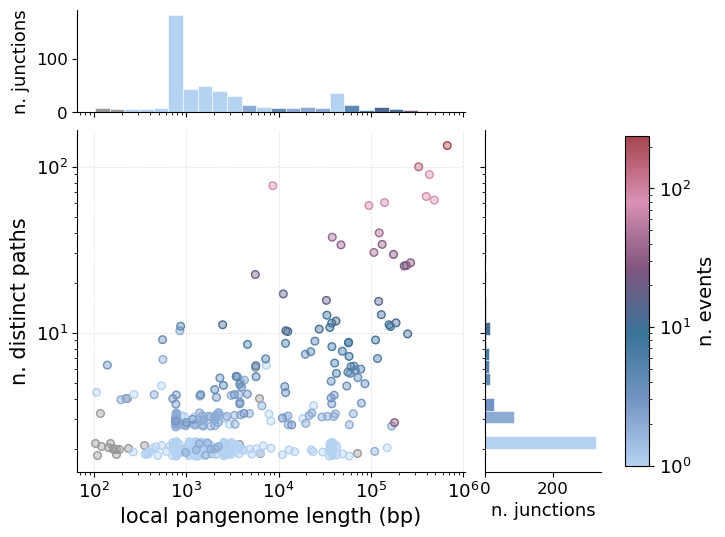

In [4]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_all,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_events",  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=1,
      scatter_size=30,
      point_linewidth=1,
      save_path="../figures/n_events_junction_diversity.pdf",
      figsize=(8,6)                                                                                                                                                                                    
  )  

Saved figure to ../figures/events_over_junction_diversity_by_type.pdf


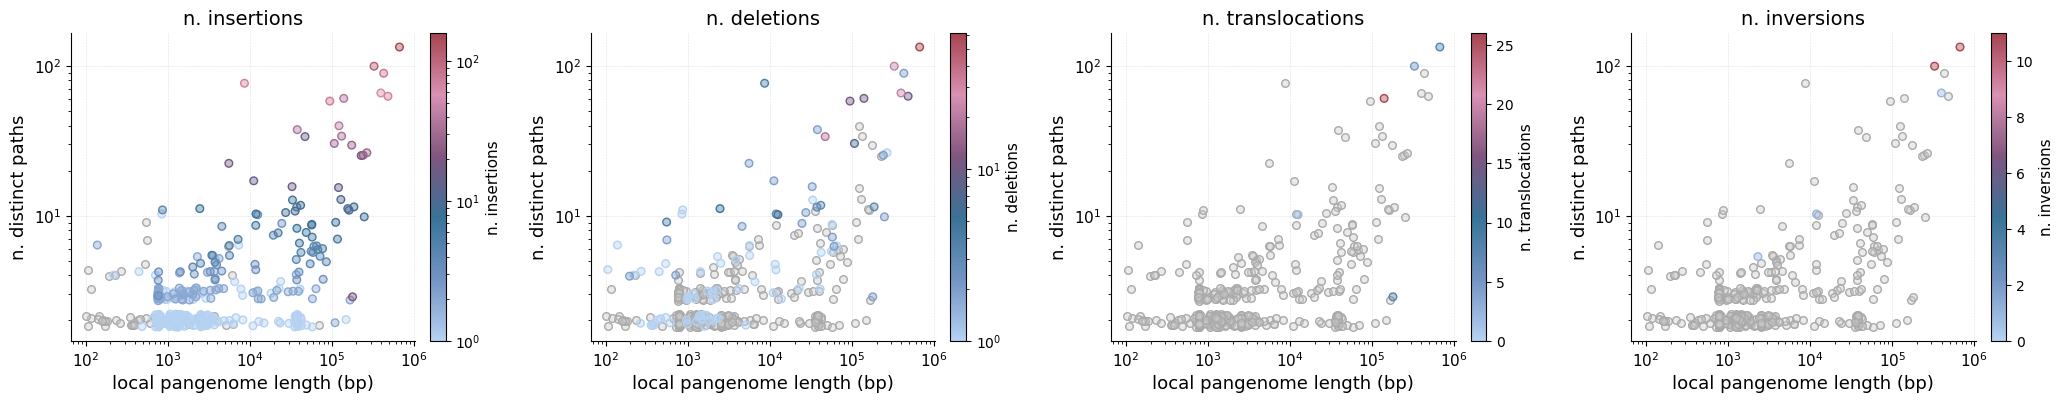

In [4]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_all,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count=["n_insertion", "n_deletion", "n_translocation", "n_inversion"],  # or "n_insertion", "n_deletion", etc.                                                                                                                              
      filled=True,
      fill_alpha=0.4,
      edge_alpha=1,
      scatter_size=30,
      point_linewidth=1,
      log_color_scale=['n_insertion', 'n_deletion'],
      subplot_arrangement=(1, 4),
      figsize=(25, 4),
      shared_colorbar=False,
      save_path = "../figures/events_over_junction_diversity_by_type.pdf"
  ) 


Saved figure to ../figures/n_trna_junction_diversity.pdf


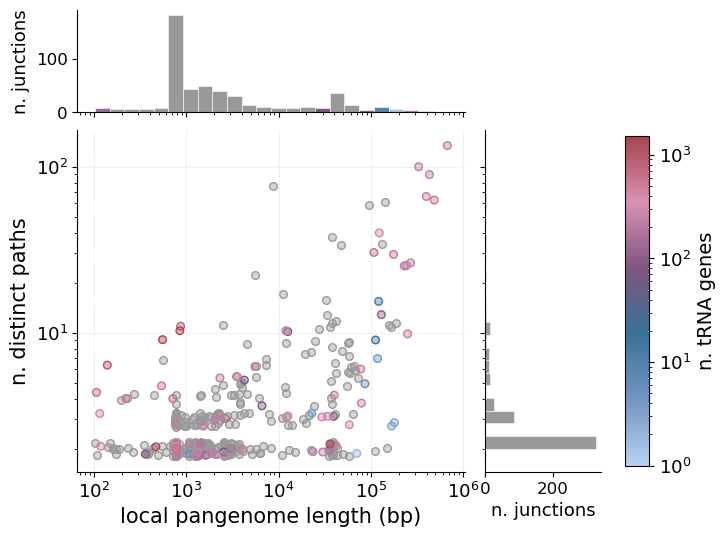

In [9]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
      jdf_all,                                                                                                                                                                                         
      x_col="tot_acc_len",                                                                                                                                                                                  
      y_col="n_categories",                                                                                                                                                                                 
      color_by_event_count="n_total_trna",  # or "n_insertion", "n_deletion", etc.
       colorbar_label="n. tRNA genes",                                                                                                                         
      filled=True,
      fill_alpha=0.4,
      edge_alpha=1,
      scatter_size=30,
      point_linewidth=1,
      save_path="../figures/n_trna_junction_diversity.pdf",
      figsize=(8,6)                                                                                                                                                                                    
  ) 

Saved figure to ../figures/events_over_junction_diversity_by_type.pdf


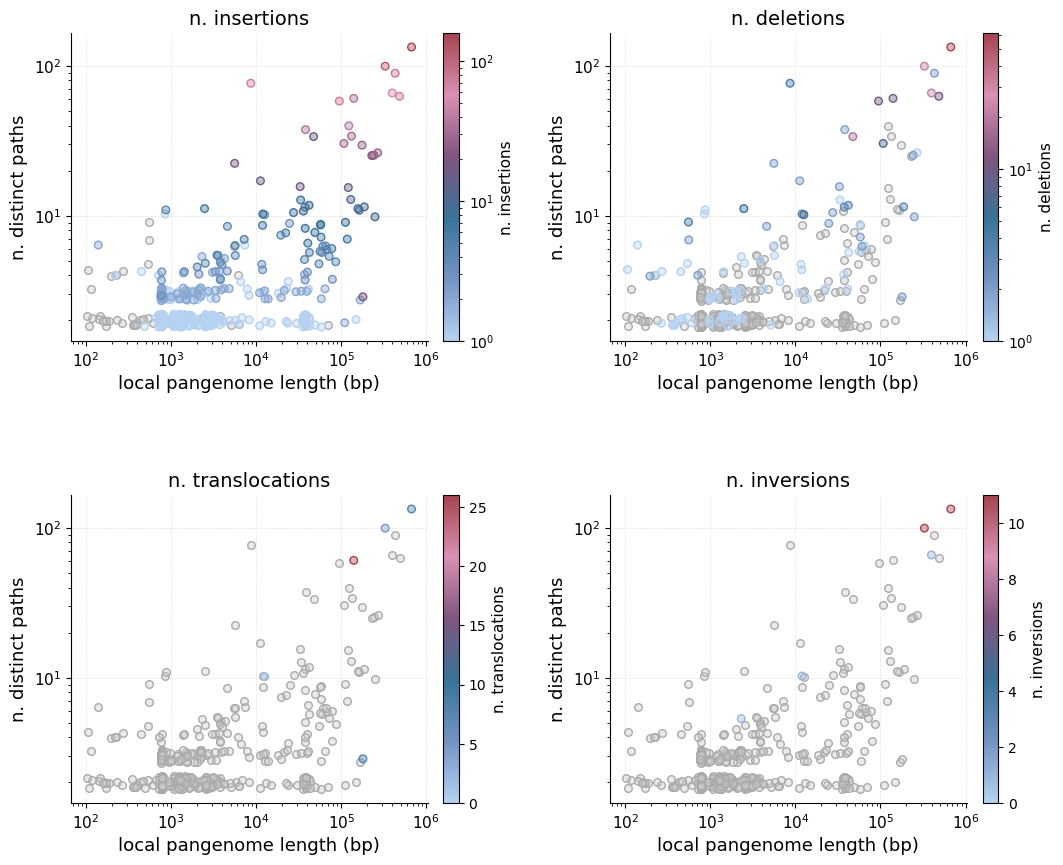

In [7]:
fig, axes = plot_marginal_scatter(                                                                                                                                                                        
    jdf_all,                                                                                                                                                                                         
    x_col="tot_acc_len",                                                                                                                                                                                  
    y_col="n_categories",                                                                                                                                                                                 
    color_by_event_count=["n_insertion", "n_deletion", "n_translocation", "n_inversion"],  # or "n_insertion", "n_deletion", etc.                                                                                                                              
    filled=True,
    fill_alpha=0.4,
    edge_alpha=1,
    scatter_size=30,
    point_linewidth=1,
    log_color_scale=['n_insertion', 'n_deletion'],
    subplot_arrangement=(2, 2),
    figsize=(12, 10),
    shared_colorbar=False,
    save_path = "../figures/events_over_junction_diversity_by_type.pdf"
) 


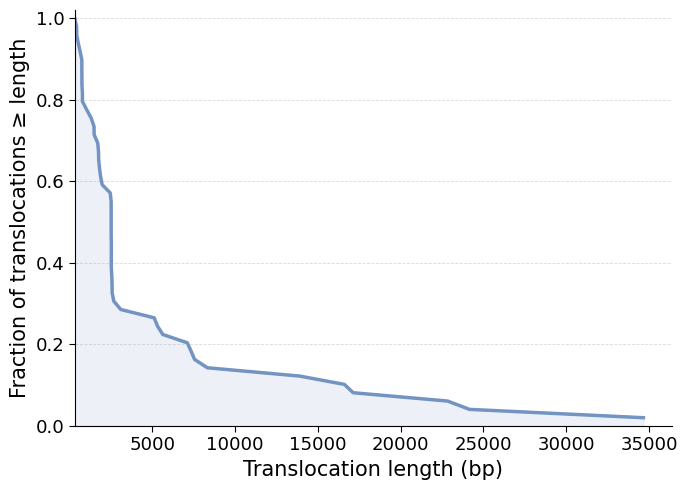

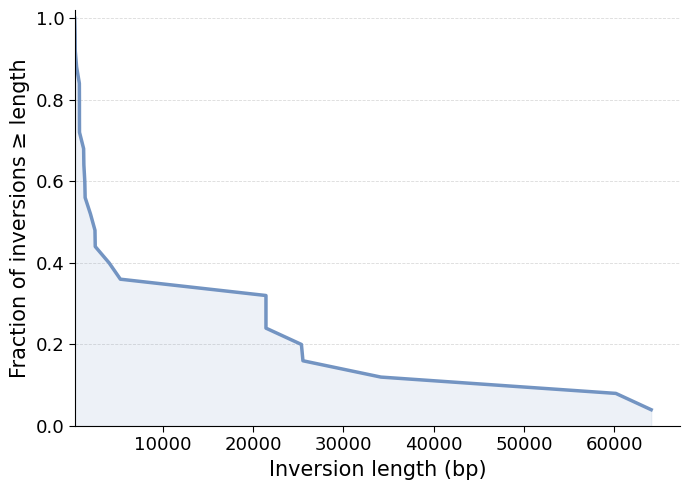

(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Inversion length (bp)', ylabel='Fraction of inversions ≥ length'>)

In [5]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
      log_y=False, log_x=False, filter_below_threshold=True,                                                                                                                                                
      ccdf_event="translocation", figsize=(7,5),                                                                                                                                                            
      #save_path="../figures/translocation_cumulative_length.pdf"
      )                                                                                                                                           
                                                                                                                                                                                                            
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
    log_y=False, log_x=False, filter_below_threshold=True,                                                                                                                                                
    ccdf_event="inversion", figsize=(7,5),                                                                                                                                                              
    #save_path="../figures/inversion_cumulative_length.pdf"
    )  

Saved figure to ../figures/deletions_cumulative_length.pdf


(<Figure size 700x500 with 1 Axes>,
 <Axes: xlabel='Deletion length (bp)', ylabel='Fraction of deletions ≥ length'>)

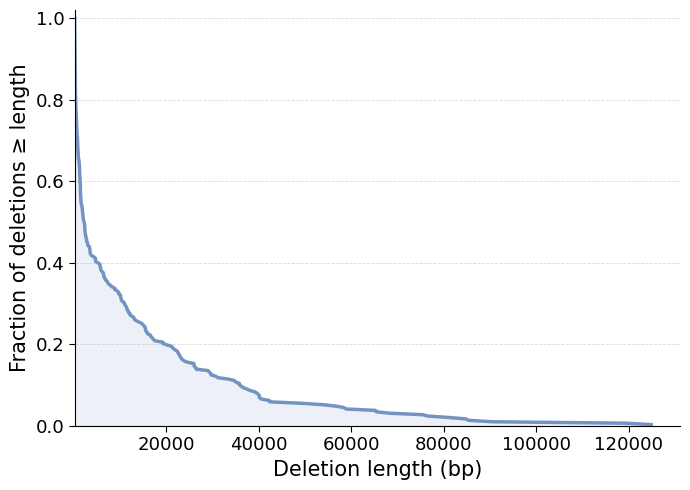

In [6]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
                                  log_y=False, log_x=False,                                                                                                                        
                                  filter_below_threshold=True, color_by_mge=True, deletions_only=True, figsize=(7,5), save_path="../figures/deletions_cumulative_length.pdf")

Saved figure to ../figures/insertion_length_MGE.pdf


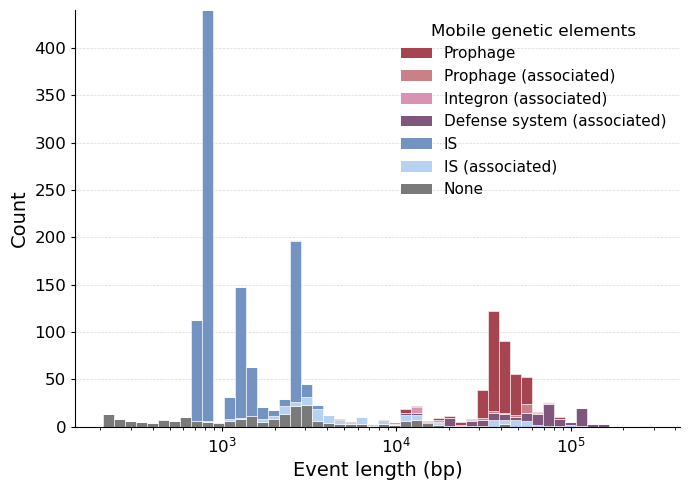

In [7]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
                                  log_y=False, log_x=True,                                                                                                                        
                                  filter_below_threshold=True, color_by_mge=True, insertions_only=True, figsize=(7,5), save_path="../figures/insertion_length_MGE.pdf")

Saved figure to ../figures/insertion_length_MGE_IS_family.pdf


(<Figure size 900x500 with 1 Axes>,
 <Axes: xlabel='Event length (bp)', ylabel='Count'>)

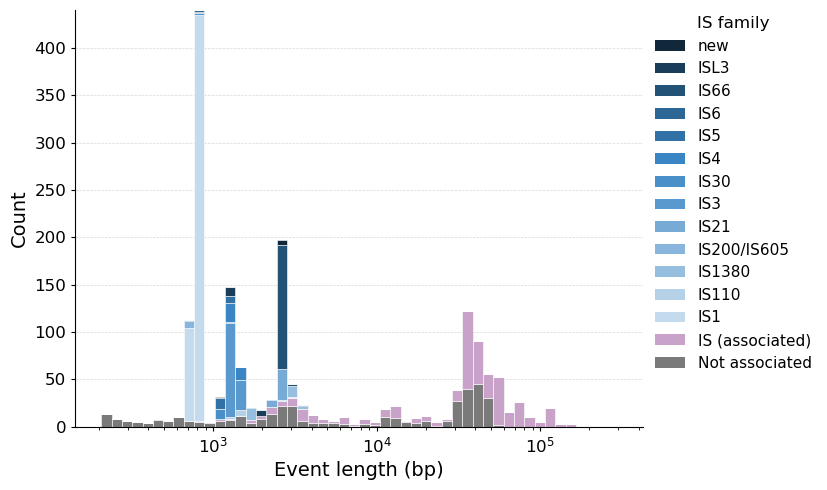

In [8]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
                                  log_y=False, log_x=True,                                                                                                                        
                                  filter_below_threshold=True, color_by_mge=True, insertions_only=True, figsize=(9,5), save_path="../figures/insertion_length_MGE_IS_family.pdf", insertions_by_is_family=True)

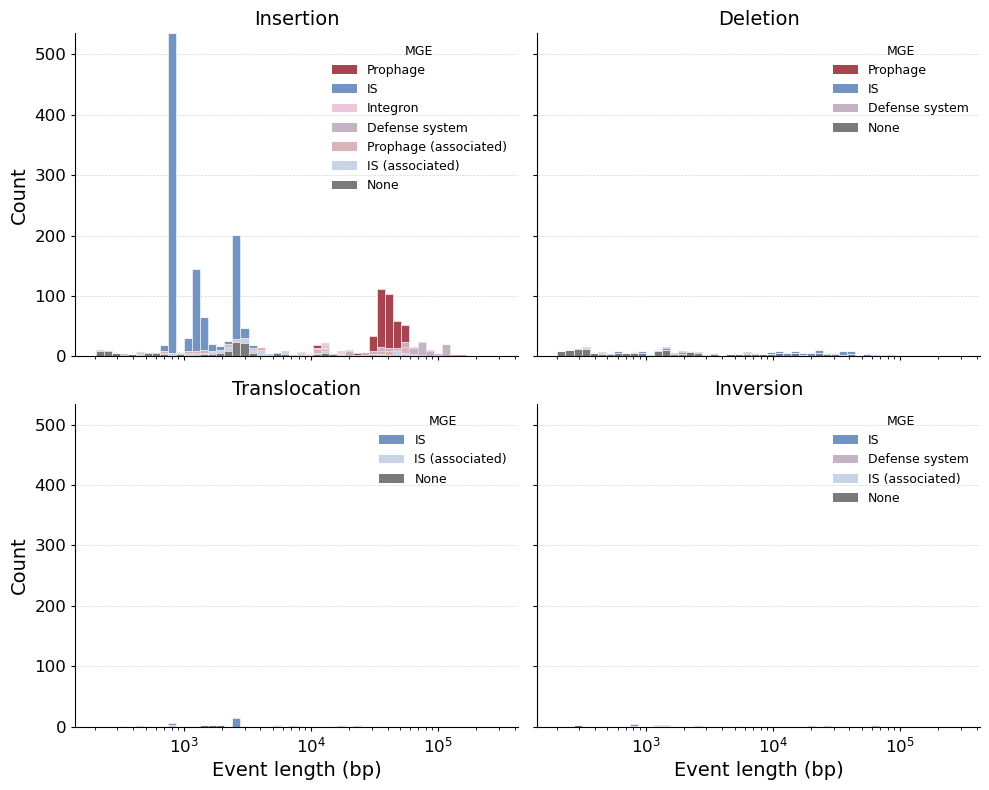

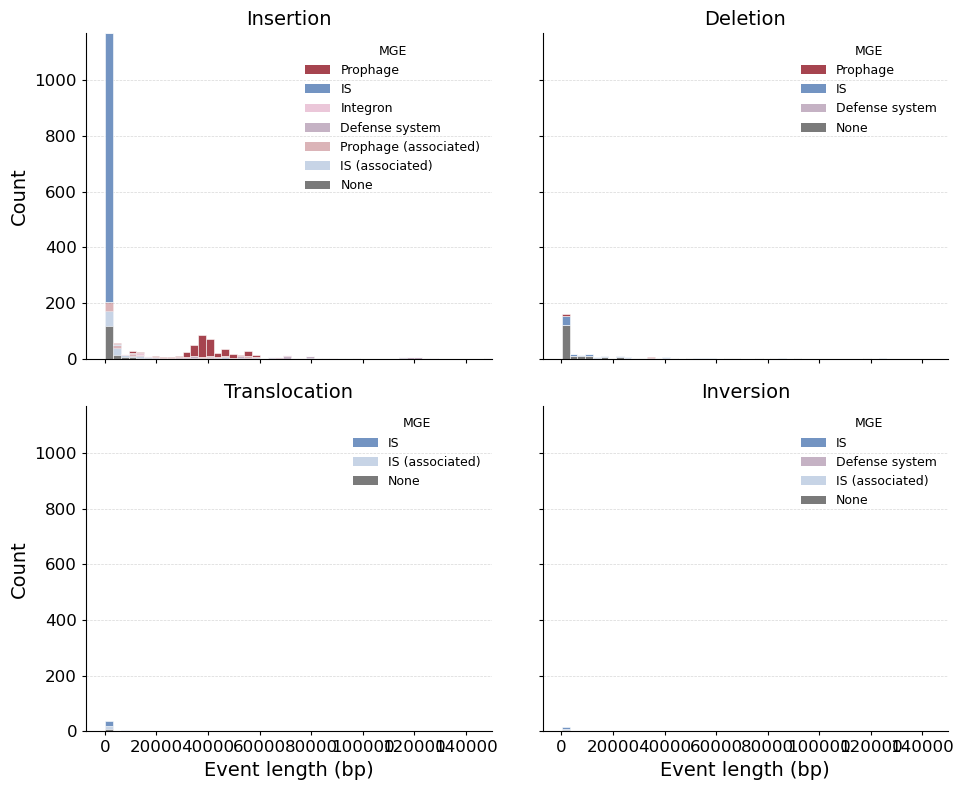

In [4]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
                                  log_y=False, log_x=True,                                                                                                                        
                                  filter_below_threshold=True, color_by_mge=True)
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200,                                                                                                                          
                                  log_y=False, log_x=False, x_max=150000,                                                                                                                        
                                  filter_below_threshold=True, color_by_mge=True)

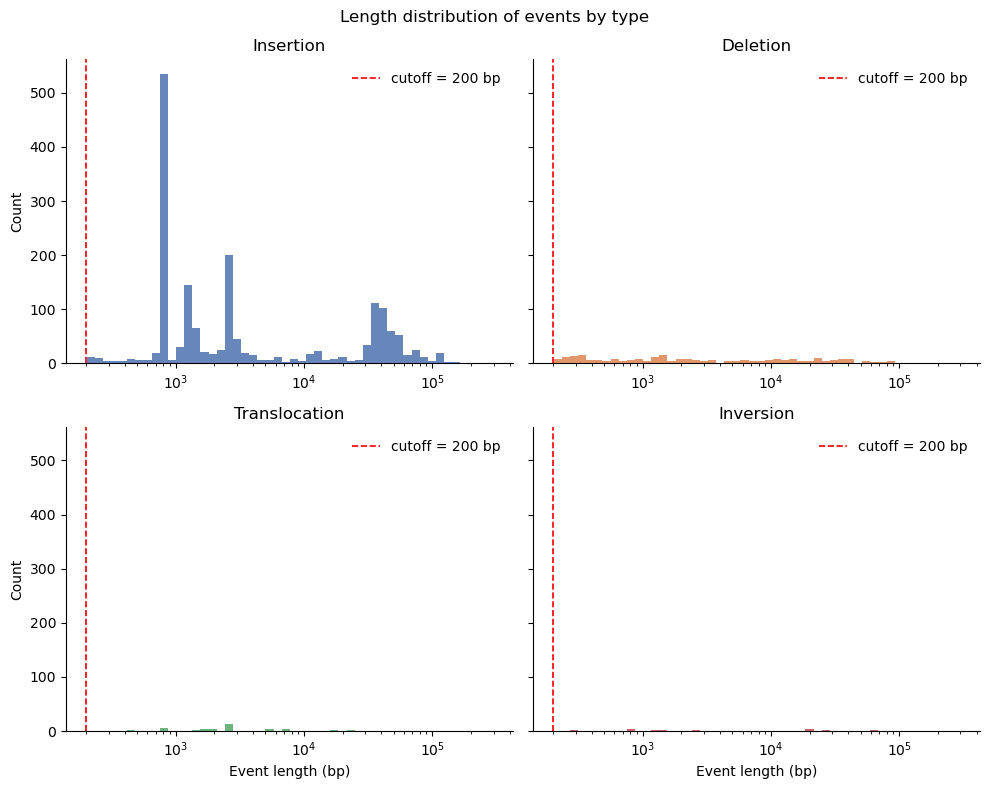

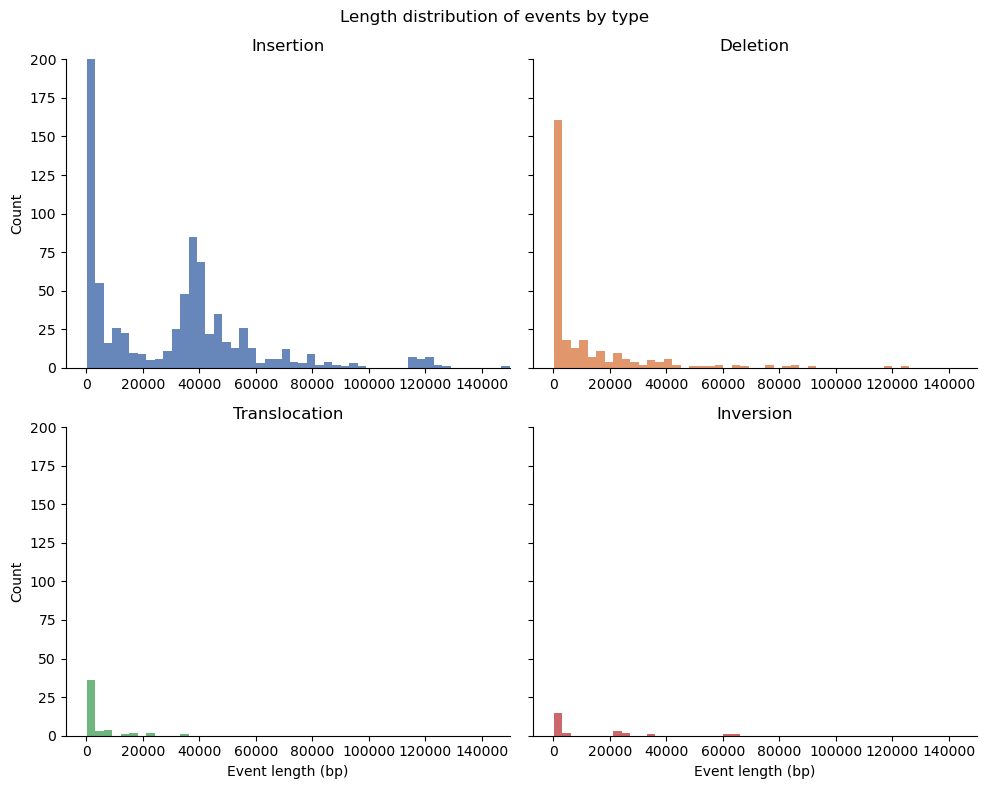

In [5]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200, log_y = False, log_x=True)
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200, log_y = False, log_x=False, y_max = 200, x_max = 150000, filter_below_threshold=True)

In [16]:
deduplicated_events_df[deduplicated_events_df['event_type'] == "insertion"].is_family.value_counts().sum()

np.int64(973)

In [20]:
deduplicated_events_df.event_type.value_counts()

event_type
insertion        1765
deletion          287
translocation      49
inversion          25
Name: count, dtype: int64

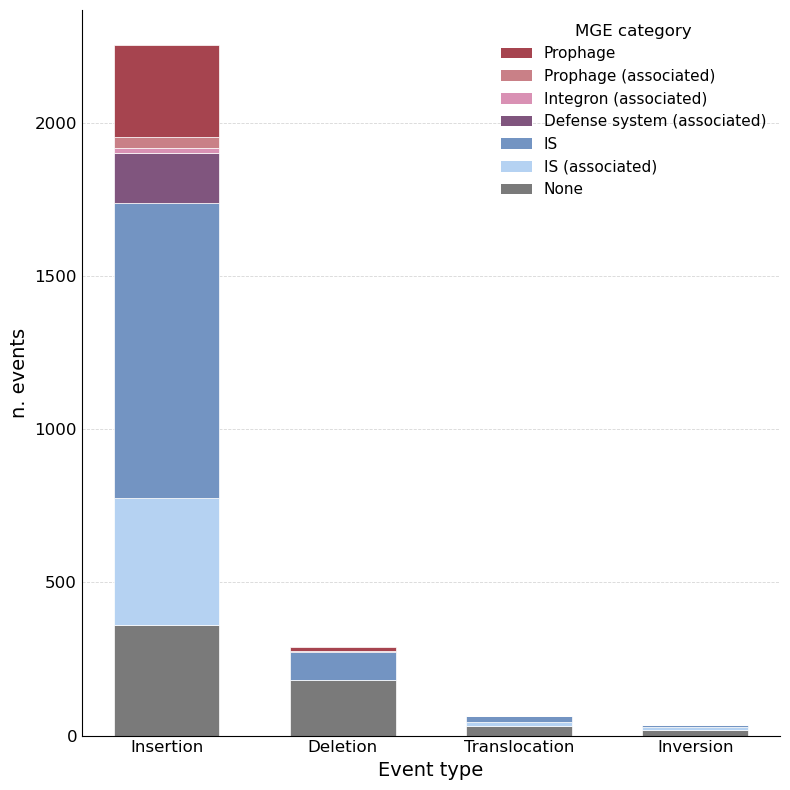

(<Figure size 800x800 with 1 Axes>,
 <Axes: xlabel='Event type', ylabel='n. events'>)

In [8]:
plot_event_mge_stacked_bar(deduplicated_events_df, figsize=(8,8))

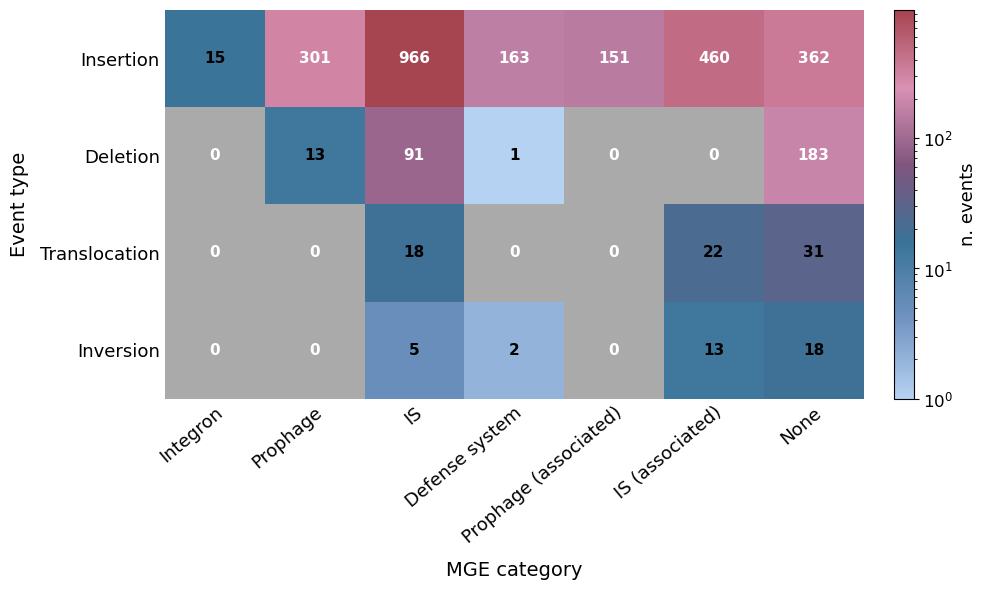

(<Figure size 1000x600 with 2 Axes>,
 <Axes: xlabel='MGE category', ylabel='Event type'>)

In [5]:
plot_event_mge_heatmap(deduplicated_events_df, figsize=(10,6))

In [ ]:
# When more than one signature MGE is present, we associated a junction with one category using assignment hierarchy: integrons > prophages > defense systems > ISs.

In [29]:
deduplicated_events_df

,event_type,junction_name,path,ctx,n_prophage,n_is,n_mge,n_integron,is_families,n_defense_system,...,fasta_path,length,strand,start_pos,end_pos,deletion,consensus_sequence,position,translocation,inversion
0,insertion,ADIVNXMSJF_r__CGRLRHSCCE_f,[10467811667185626553|+|],12675429639006275041,1,0,1,0,[],0,...,../results/atb_lookup_0001/insertions/ADIVNXMS...,10981,+,4283.0,15264.0,NaN,NaN,NaN,NaN,NaN
1,insertion,ADOVFNSINA_f__ECOWCWQMQJ_f,[2885183895822662185|+|],12863862502596669040,0,1,1,0,[IS1],0,...,../results/atb_lookup_0001/insertions/ADOVFNSI...,777,+,7189.0,7966.0,NaN,NaN,NaN,NaN,NaN
2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],6295978535415985145,0,1,1,0,[IS1],0,...,../results/atb_lookup_0001/insertions/ADOVFNSI...,765,+,7190.0,7955.0,NaN,NaN,NaN,NaN,NaN
3,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,[6114133947861579624|+|],16305501466558477249,0,1,1,0,[IS1],0,...,../results/atb_lookup_0001/insertions/ADOVFNSI...,777,+,11941.0,12718.0,NaN,NaN,NaN,NaN,NaN
4,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,[1233050476806559636|+|],13278839926153538614,0,1,1,0,[IS1],0,...,../results/atb_lookup_0001/insertions/AEJQYPEV...,776,+,2502.0,3278.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2177,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,[14278357606779827683|+|3719368368610427324_1]...,3719368368610427392.0,0,1,1,0,[IS1],0,...,NaN,768,+,13992.0,14760.0,NaN,NaN,NaN,NaN,inversion0
2178,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,[4021125573603756180|-|17559535791254520085_1]...,4665049444119171072.0,0,1,1,0,[IS66],0,...,NaN,2519,-,47817.0,50336.0,NaN,NaN,NaN,NaN,inversion0
2179,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,[4688440610462638740|-|]_[3487287346370703245|...,15908320088543975424.0,0,0,0,0,[],0,...,NaN,5303,-,15799.0,21102.0,NaN,NaN,NaN,NaN,inversion0
2180,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,[5853345250725139292|+|15908320088543975006_1]...,7177061195065662464.0,0,1,1,0,[IS66],0,...,NaN,1989,+,42761.0,44750.0,NaN,NaN,NaN,NaN,inversion0


In [7]:
deduplicated_events_df.groupby("event_type")["n_mge"].value_counts().unstack(fill_value=0)         

n_mge,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,22,30,37
event_type,,,,,,,,,,,,,,,,,,,,,
ambiguous_insertion,22,24,8,5,2,2,4,5,2,2,...,10,3,2,3,0,0,0,0,0,1
deletion,344,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
insertion,151,1111,237,89,32,30,18,13,8,17,...,15,7,4,4,1,2,1,1,1,1
inversion,7,12,1,0,0,2,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
translocation,11,26,5,2,4,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
grouped = deduplicated_events_df.groupby("event_type")["n_mge"]                                                                                                                                           
counts = grouped.value_counts().unstack(fill_value=0)                                                                                                                                                     
counts["n_with_mge"] = grouped.apply(lambda x: (x > 0).sum())                                                                                                                                             
counts

n_mge,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,22,30,37,n_with_mge
event_type,,,,,,,,,,,,,,,,,,,,,
ambiguous_insertion,22,24,8,5,2,2,4,5,2,2,...,3,2,3,0,0,0,0,0,1,78
deletion,344,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
insertion,151,1111,237,89,32,30,18,13,8,17,...,7,4,4,1,2,1,1,1,1,1614
inversion,7,12,1,0,0,2,1,1,0,1,...,0,0,0,0,0,0,0,0,0,18
translocation,11,26,5,2,4,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,38


In [6]:
deduplicated_events_df.n_mge.value_counts()

n_mge
1     1173
0      535
2      251
3       96
4       38
5       34
14      25
6       24
9       20
7       19
8       10
15      10
13       8
12       7
17       7
16       6
10       6
11       6
19       2
37       2
18       1
22       1
30       1
20       1
Name: count, dtype: int64

In [4]:
summaries_annotated['insertions']

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx,n_prophage,n_integron,n_defense_system,n_is,is_families,n_mge
0,ADIVNXMSJF_r__CGRLRHSCCE_f,consensus_1,NZ_CP103562.1,[10467811667185626553|+|],segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283,15264,12675429639006275041,1,0,0,0,[],1
1,ADOVFNSINA_f__ECOWCWQMQJ_f,consensus_1,NZ_CP116085.1,[2885183895822662185|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189,7966,12863862502596669040,0,0,0,1,[IS1],1
2,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_CP107153.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941,12718,16305501466558477249,0,0,0,1,[IS1],1
3,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_AP022044.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,6295978535415985145,0,0,0,1,[IS1],1
4,AEJQYPEVQR_f__SQYOENFQOY_f,consensus_1,NZ_OX030701.1,[1233050476806559636|-|],segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,2793,3570,3579820473221573810,0,0,0,1,[IS1],1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8082,YJSEGEHASG_r__YWSGZOAHNX_r,consensus_1,NZ_CP019012.1,[3886675241220391455|+|],segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,58257,60797,12716710876323799779,0,0,0,1,[IS66],1
8083,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104846.1,[3870718793672684742|+|5120184519711206319_1],segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,60231,60999,5120184519711206319,0,0,0,1,[IS1],1
8084,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104848.1,[2624032834068938794|+|]_[1528420688200569391|...,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,60231,180320,5120184519711206319,0,0,3,16,"[IS66, IS3, IS1380, IS5, IS3, IS1, IS3, IS66, ...",19
8085,YVEVUPDYEE_f__ZFYFAGFPQE_f,consensus_1,NZ_CP124436.1,[213612989930417787|+|],segment_0,../results/atb_lookup/insertions/YVEVUPDYEE_f_...,42512,+,8832,51344,2622873865824788133,1,0,0,1,[IS21],2


In [6]:
summaries_annotated['insertions'].n_integron.value_counts()

n_integron
0    6714
1      19
2       1
6       1
Name: count, dtype: int64

In [5]:
summaries_annotated['insertions'][summaries_annotated['insertions']['n_integron'] > 0]

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx,n_prophage,n_integron,n_defense_system,n_is,is_families,n_mge
938,DSLXSJZSTL_r__QQSILILDBT_r,consensus_1,NZ_CP103557.1,[10889658175742306187|+|],segment_0,../results/atb_lookup/insertions/DSLXSJZSTL_r_...,16910,+,1125,18035,3147349976904771225,0,2,0,7,"[IS6, IS6, IS6, IS6, IS6, IS6, IS6]",9
4122,HKKMVAAVLK_r__KJFGXXNSDH_r,consensus_1,NZ_CP107128.1,[3458966406585585106|+|],segment_0,../results/atb_lookup/insertions/HKKMVAAVLK_r_...,23534,+,2198,25732,11844348572115462443,0,1,1,7,"[new, new, IS6, IS6, IS3, IS6, IS1380]",9
6189,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP107153.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,12301,+,6424,18729,7910028013055703148,0,1,0,8,"[IS6, IS6, IS1380, new, IS6, IS6, IS3, IS6]",9
6190,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP107120.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,16926,+,6423,23359,7910028013055703148,0,1,0,7,"[IS6, IS6, IS6, IS6, IS3, IS6, IS6]",8
6192,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP049077.2,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,12950,+,6425,19377,7910028013055703148,0,1,0,8,"[IS6, IS1380, new, IS6, IS6, IS3, IS6, IS6]",9
6194,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_OY019088.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,12950,+,6424,19378,7910028013055703148,0,1,0,8,"[IS6, IS6, IS3, IS6, IS6, new, IS1380, IS6]",9
6195,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP103672.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,70180,+,6423,76617,7910028013055703148,0,6,0,24,"[IS6, IS6, IS6, IS6, IS6, IS6, IS6, IS6, IS6, ...",30
6197,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP018991.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,12121,+,6426,18634,7910028013055703148,0,1,0,7,"[IS6, IS3, IS6, IS6, new, IS1380, IS6]",8
6198,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP115324.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,12950,+,6424,19378,7910028013055703148,0,1,0,8,"[IS6, IS6, IS3, IS6, IS6, new, IS1380, IS6]",9
6199,KGJXRPELGX_r__KIVDDRSTJR_r,consensus_1,NZ_CP103557.1,[15754159961266729618|+|588656222521101540_1]_...,segment_0,../results/atb_lookup/insertions/KGJXRPELGX_r_...,8861,+,6423,15286,7910028013055703148,0,1,0,4,"[IS6, IS6, IS6, IS6]",5


In [10]:
annotations.groupby("feature")["overlaps_event"].value_counts().unstack(fill_value=0)                                                                                                                     

overlaps_event,False,True
feature,,
CALIN,3,27
IS,11121,5801
complete,0,3
defense_system,1710,562
prophage,617,1232


In [17]:
junction_name = "CIRMBUYJFK_f__CWCCKOQCWZ_r"
read_gff3_annotations(f"../results/junction_mges/{junction_name}.gff3")

,seqid,feature,start,end,length,attrs,is_subtype
0,NZ_CP096110.1,prophage,3673,45291,41618,{'ID': 'NZ_CP096110.1|provirus_2201026_2242644...,None
1,NZ_CP014497.1,prophage,3673,45290,41617,{'ID': 'NZ_CP014497.1|provirus_2095135_2136752...,None
2,NZ_CP014495.1,prophage,3673,45290,41617,{'ID': 'NZ_CP014495.1|provirus_2054003_2095620...,None
3,NZ_CP107147.1,prophage,3673,45291,41618,"{'ID': 'NZ_CP107147.1|provirus_634642_676260',...",None
4,NZ_LS999560.1,prophage,3673,45292,41619,{'ID': 'NZ_LS999560.1|provirus_2045733_2087352...,None
...,...,...,...,...,...,...,...
211,NZ_CP102061.1,prophage,3673,45290,41617,"{'ID': 'NZ_CP102061.1|provirus_583590_625207',...",None
212,NZ_CP124400.1,prophage,3673,45292,41619,"{'ID': 'NZ_CP124400.1|provirus_585267_626886',...",None
213,NZ_CP035516.1,prophage,3673,45292,41619,{'ID': 'NZ_CP035516.1|provirus_2045248_2086867...,None
214,NZ_CP107151.1,IS,19250,20017,767,"{'ID': 'NZ_CP107151.1|IS1|10126', 'is_partial'...",IS1


In [15]:
# events must be related to mge annotation prior to deduplication
summaries['insertions']

,junction_name,consensus,genome_name,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx
0,ADIVNXMSJF_r__CGRLRHSCCE_f,consensus_1,NZ_CP103562.1,[10467811667185626553|+|],segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283,15264,12675429639006275041
1,ADOVFNSINA_f__ECOWCWQMQJ_f,consensus_1,NZ_CP116085.1,[2885183895822662185|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189,7966,12863862502596669040
2,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_CP107153.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941,12718,16305501466558477249
3,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,NZ_AP022044.1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190,7955,6295978535415985145
4,AEJQYPEVQR_f__SQYOENFQOY_f,consensus_1,NZ_OX030701.1,[1233050476806559636|-|],segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,2793,3570,3579820473221573810
...,...,...,...,...,...,...,...,...,...,...,...
8082,YJSEGEHASG_r__YWSGZOAHNX_r,consensus_1,NZ_CP019012.1,[3886675241220391455|+|],segment_0,../results/atb_lookup/insertions/YJSEGEHASG_r_...,2540,+,58257,60797,12716710876323799779
8083,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104846.1,[3870718793672684742|+|5120184519711206319_1],segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,768,+,60231,60999,5120184519711206319
8084,YUOECYBHUS_f__ZTHKZYHPIX_f,consensus_1,NZ_CP104848.1,[2624032834068938794|+|]_[1528420688200569391|...,segment_0,../results/atb_lookup/insertions/YUOECYBHUS_f_...,120075,+,60231,180320,5120184519711206319
8085,YVEVUPDYEE_f__ZFYFAGFPQE_f,consensus_1,NZ_CP124436.1,[213612989930417787|+|],segment_0,../results/atb_lookup/insertions/YVEVUPDYEE_f_...,42512,+,8832,51344,2622873865824788133


In [12]:
deduplicated_events_df

,event_type,junction_name,consensus,path,insertion,fasta_path,length,strand,start_pos,end_pos,ctx,deletion,consensus_sequence,position,translocation,inversion
0,insertion,ADIVNXMSJF_r__CGRLRHSCCE_f,consensus_1,[10467811667185626553|+|],segment_0,../results/atb_lookup/insertions/ADIVNXMSJF_r_...,10981,+,4283.0,15264.0,12675429639006275041,NaN,NaN,NaN,NaN,NaN
1,insertion,ADOVFNSINA_f__ECOWCWQMQJ_f,consensus_1,[2885183895822662185|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_f_...,777,+,7189.0,7966.0,12863862502596669040,NaN,NaN,NaN,NaN,NaN
2,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,777,+,11941.0,12718.0,16305501466558477249,NaN,NaN,NaN,NaN,NaN
3,insertion,ADOVFNSINA_r__CAPUVXKIHV_r,consensus_1,[6114133947861579624|+|],segment_0,../results/atb_lookup/insertions/ADOVFNSINA_r_...,765,+,7190.0,7955.0,6295978535415985145,NaN,NaN,NaN,NaN,NaN
4,insertion,AEJQYPEVQR_f__SQYOENFQOY_f,consensus_1,[1233050476806559636|-|],segment_0,../results/atb_lookup/insertions/AEJQYPEVQR_f_...,768,-,2793.0,3570.0,3579820473221573810,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2255,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,[14278357606779827683|+|3719368368610427324_1]...,NaN,NaN,768,+,13992.0,14760.0,3719368368610427392.0,NaN,NaN,NaN,NaN,inversion0
2256,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,[12328260769168341665|-|]_[7177061195065662354...,NaN,NaN,25526,-,15798.0,41324.0,15908320088543975424.0,NaN,NaN,NaN,NaN,inversion0
2257,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,[14278357606779827683|+|17687220482716050848_1...,NaN,NaN,760,+,14457.0,15217.0,17687220482716051456.0,NaN,NaN,NaN,NaN,inversion0
2258,inversion,XXVMWZCEKI_r__YUOECYBHUS_r,consensus_1,[14278357606779827683|+|15908320088543975006_1...,NaN,NaN,775,+,14957.0,18264.0,15908320088543975424.0,NaN,NaN,NaN,NaN,inversion0


In [8]:
jdf_all = pd.read_csv("../results/junction_summary_df.csv")

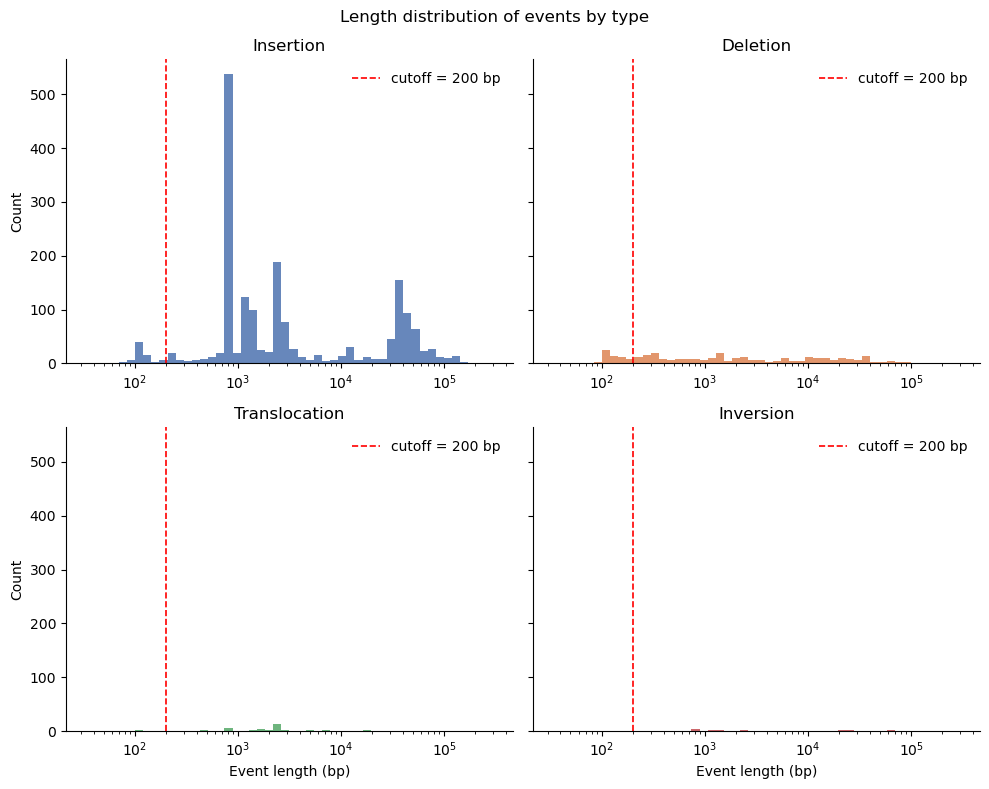

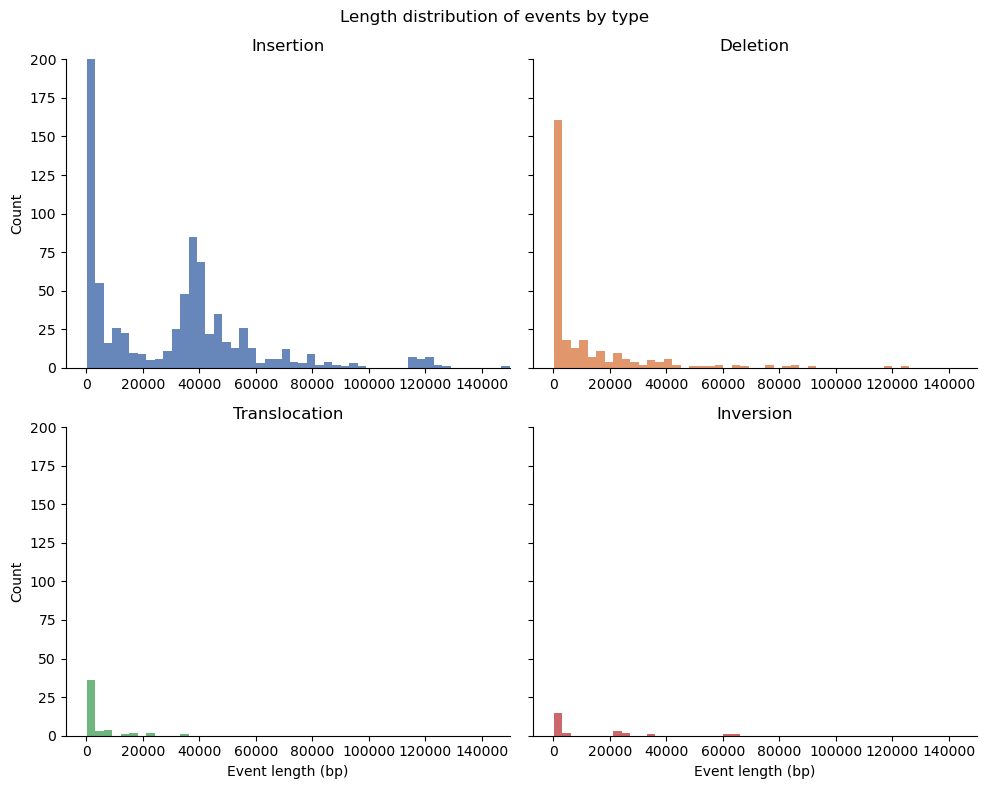

In [11]:
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200, log_y = False, log_x=True)
plot_event_length_distribution(deduplicated_events_df, min_length_threshold=200, log_y = False, log_x=False, y_max = 200, x_max = 150000, filter_below_threshold=True)

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2097: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



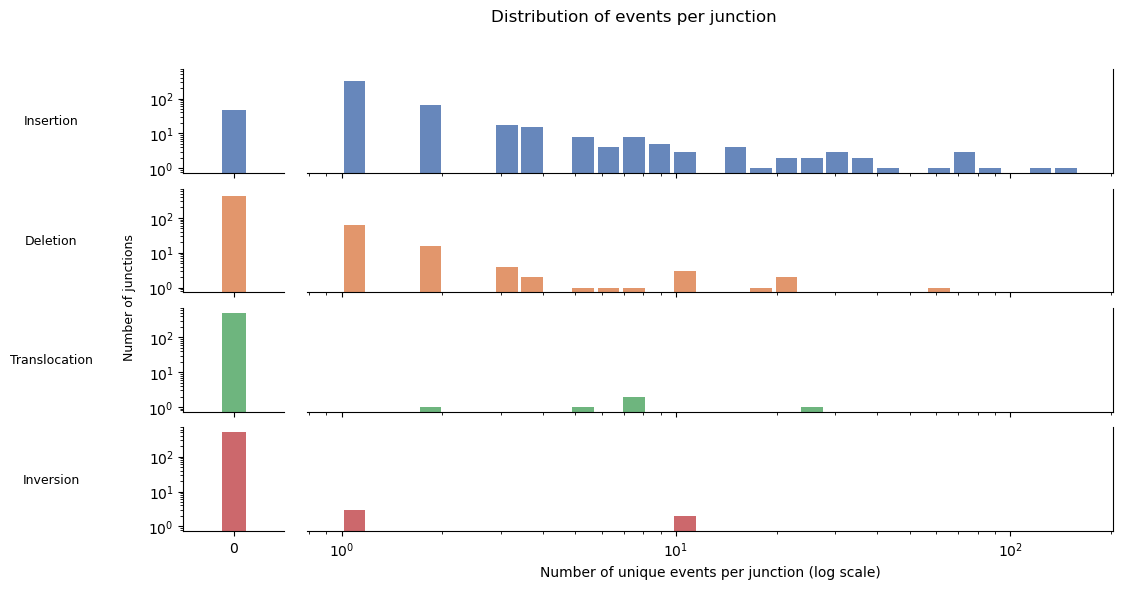

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2097: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



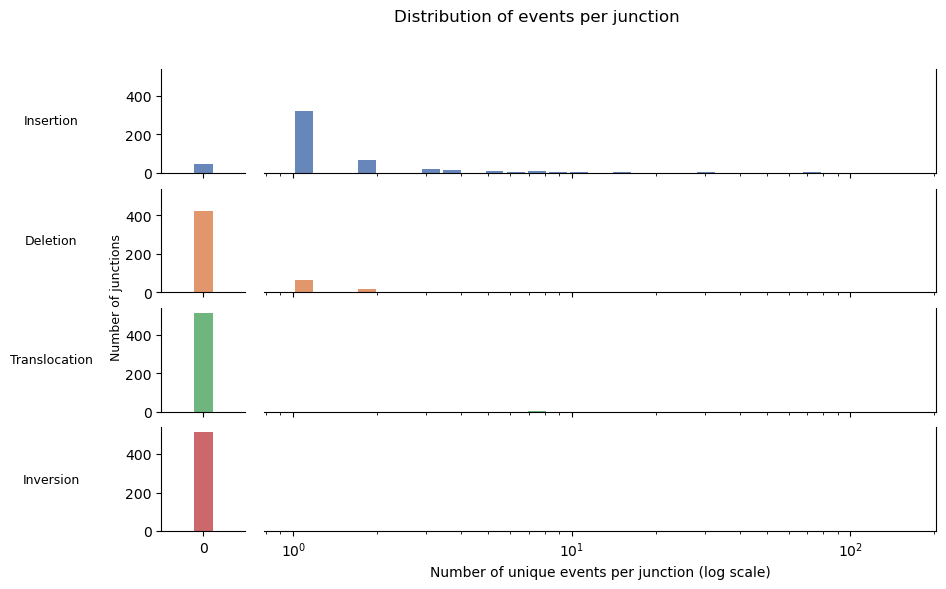

In [9]:
plot_event_counts_distribution(jdf_all, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(jdf_all, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

In [9]:
jdf_all[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()

n_insertion        1802.0
n_deletion          305.0
n_translocation      51.0
n_inversion          26.0
n_events           2184.0
dtype: float64

In [15]:
base_path = Path("../results/atb_lookup_0001")

_fname = f"../config/junction_stats.csv"
jdf = pd.read_csv(_fname)
jdf

# summarize results
cluster_df = pd.read_csv("../results/consensus_analysis/cluster_maps_0_001.csv")
trna_counts_df = count_trna_per_junction(annotations_dir="../results/junction_annotations",
    category_bins=[-1, 0, 50, 300, float("inf")], category_labels=["0", "1–50", "50–300", ">300"],)
summaries = combine_all_junctions_summaries(str(base_path), save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path=f"{base_path}/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"{base_path}/event_counts_per_junction.csv")
#ji_df = pd.read_csv("../results/consensus_analysis/mean_diversity_per_junction.csv") 

jdf_trna = jdf.copy().merge(trna_counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                 
jdf_clusters = jdf_trna.merge(cluster_df[["junction_name", "n_clusters"]].set_index("junction_name"), left_on="edge", right_index=True, how="left")

jdf_all = jdf_clusters.merge(counts_df.set_index("junction_name"), left_on="edge", right_index=True, how="left")                                                                                                                              
jdf_all[counts_df.columns.drop("junction_name")] = jdf_all[counts_df.columns.drop("junction_name")].fillna(0)

#jdf_all = jdf_all.merge(ji_df.set_index("junction_name"), left_on="edge", right_index = True, how="left")  

jdf_all.rename(columns={"edge": "junction_name"}, inplace=True)

# only continue with junctions that have at least 2 different paths, otherwise they are not junctions (could happen because of duplications to elsewhere or syntheny breaks) 
jdf_all = jdf_all[jdf_all["n_categories"] >= 2]
# for now don't filter out junctions with only very few isolates, but might generally make sense to do so

jdf_hotspot = jdf_all[jdf_all["n_categories"] > 2]
jdf_nonsingleton = jdf_all[jdf_all["singleton"] == False]
jdf_binary = jdf_all[jdf_all["n_categories"] == 2]
jdf_singleton = jdf_binary[jdf_binary["singleton"] == True]
jdf_binary_nonsingleton = jdf_binary[jdf_binary["singleton"] == False]

nonbinary_junctions = jdf_all[jdf_all['n_categories'] > 2].junction_name.tolist()                                                                                                                                                                                                                                                                               
summary_df_nb = deduplicated_events_df[deduplicated_events_df['junction_name'].isin(nonbinary_junctions)]

Saved insertions summary to ../results/atb_lookup_0001/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup_0001/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_0001/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_0001/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_0001/deduplicated_events.csv
Saved event counts to ../results/atb_lookup_0001/event_counts_per_junction.csv


/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2078: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



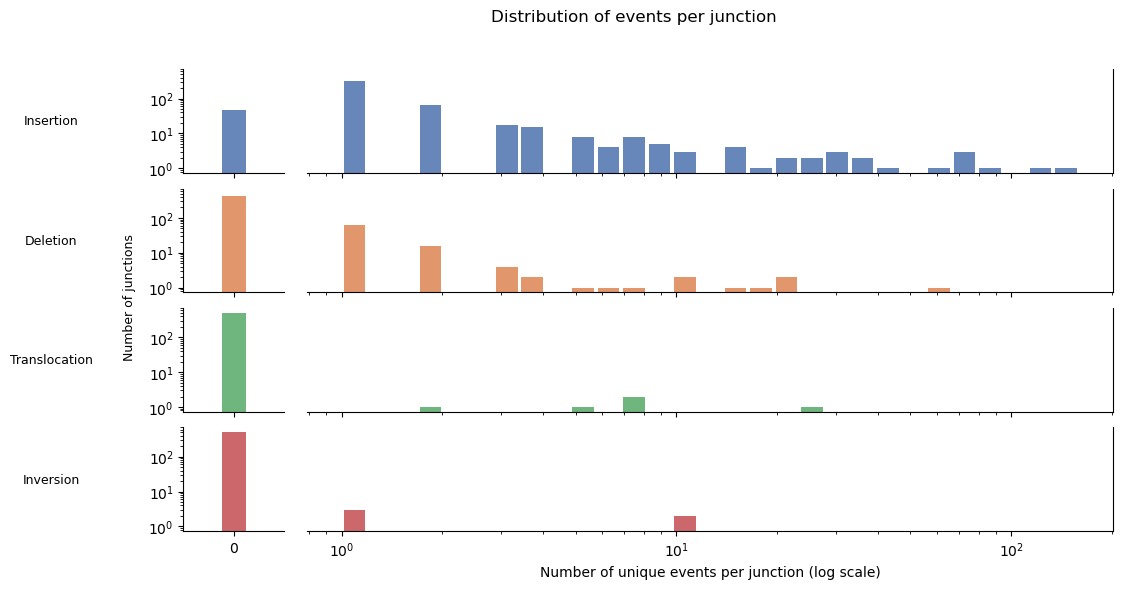

/Users/mariebecker/Documents/Uni/ETH/Masterarbeit/marie-junctions/junction_analysis/plotting.py:2078: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



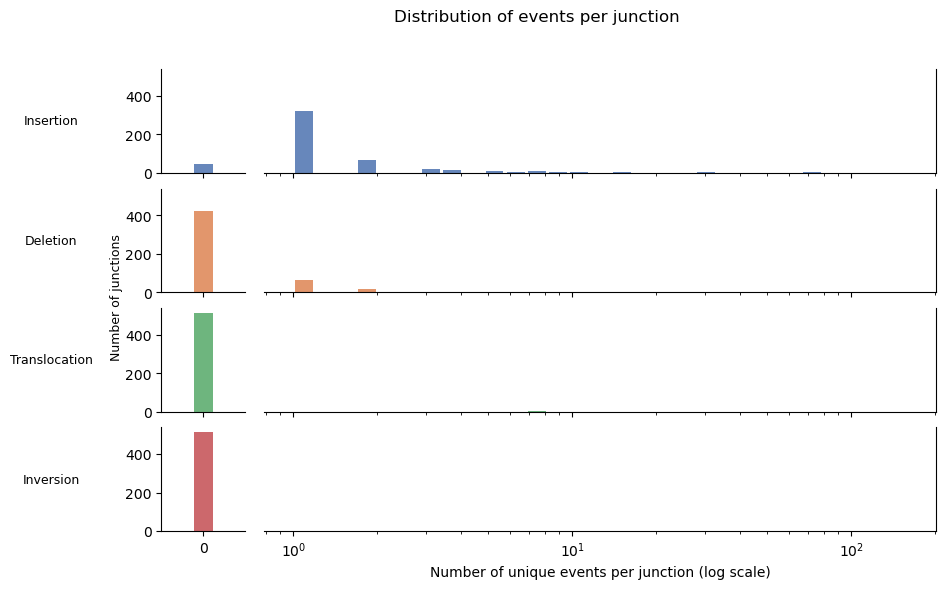

In [12]:
plot_event_counts_distribution(jdf_all, figsize=(12, 6), log_x = True, log_y = True, subplots = True)
plot_event_counts_distribution(jdf_all, figsize=(10, 6), log_x = True, log_y = False, subplots = True)

### Systematically analyze number of events for different clustering thresholds

In [15]:
summaries = combine_all_junctions_summaries(f"../results/atb_lookup", save_df=True)
deduplicated_events_df = deduplicate_events(summaries, save_path=f"../results/atb_lookup/deduplicated_events.csv")  
counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"../results/atb_lookup/event_counts_per_junction.csv")

n_insertions, n_deletions, n_translocations, n_inversions, n_events = counts_df[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()


Saved insertions summary to ../results/atb_lookup/insertions/all_junctions_insertions.csv
Saved deletions summary to ../results/atb_lookup/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup/deduplicated_events.csv
Saved event counts to ../results/atb_lookup/event_counts_per_junction.csv


In [8]:
all_results = []
tree_path = "../config/polished_tree.nwk"
jdf_all = pd.read_csv("../results/junction_summary_df.csv")


for thresh in ['05', '1', '2', '3', '4', '5', '6']:
    cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_00{thresh}.csv")
    n_junctions_with_clusters = len(cluster_df[cluster_df['n_clusters']>1])
    n_additional_clusters = cluster_df.n_clusters.sum() - len(cluster_df)

    summaries = combine_all_junctions_summaries(f"../results/atb_lookup_000{thresh}", save_df=True)
    deduplicated_events_df = deduplicate_events(summaries, save_path=f"../results/atb_lookup_000{thresh}/deduplicated_events.csv")  
    counts_df = count_events_per_junction(deduplicated_events_df, min_length=200, save_path=f"../results/atb_lookup_000{thresh}/event_counts_per_junction.csv")

    n_insertions, n_deletions, n_translocations, n_inversions, n_events = counts_df[['n_insertion', 'n_deletion', 'n_translocation', 'n_inversion', 'n_events']].sum()

    per_cluster_parsimony_df = pd.read_csv(f"../results/consensus_analysis/parsimonious_clusters_000{thresh}.csv")
    per_cluster_parsimony_df = per_cluster_parsimony_df[per_cluster_parsimony_df.junction_name.isin(jdf_all.junction_name.to_list())]
    multi_cluster_df = per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].copy()
    n_clusters_not_consistent = (multi_cluster_df["n_parsimony_steps"] > 1).sum()
    inconsistant_junctions = multi_cluster_df.loc[multi_cluster_df["n_parsimony_steps"] > 1, "junction_name"].nunique()
    n_clusters_in_multi_cluster_junctions = len(multi_cluster_df) # total number of clusters in junctions with > 1 cluster

    result_dict = {
        "threshold": f"0.00{thresh}",
        "n_junctions_with_clusters": len(per_cluster_parsimony_df[per_cluster_parsimony_df["n_clusters"] > 1].junction_name.unique()),
        "n_additional_clusters": n_additional_clusters,
        "n_insertions": n_insertions,
        "n_deletions": n_deletions,
        "n_translocations": n_translocations,
        "n_inversions": n_inversions,
        "n_events": n_events,
        "n_inconsistant_cluster": n_clusters_not_consistent,
        "n_inconsistant_junctions": inconsistant_junctions,
        "n_cluster_multicluster_junctions": n_clusters_in_multi_cluster_junctions, # different from n_additional clusters because it only considers some junctions instead of one cluster less per junction
    }

    all_results.append(result_dict)

results_df = pd.DataFrame(all_results)

    

Saved insertions summary to ../results/atb_lookup_00005/insertions/all_junctions_insertions.csv
No ambiguous_insertions found across any junction.
Saved deletions summary to ../results/atb_lookup_00005/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_00005/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_00005/inversions/all_junctions_inversions.csv
Saved deduplicated events to ../results/atb_lookup_00005/deduplicated_events.csv
Saved event counts to ../results/atb_lookup_00005/event_counts_per_junction.csv
Saved insertions summary to ../results/atb_lookup_0001/insertions/all_junctions_insertions.csv
No ambiguous_insertions found across any junction.
Saved deletions summary to ../results/atb_lookup_0001/deletions/all_junctions_deletions.csv
Saved translocations summary to ../results/atb_lookup_0001/translocations/all_junctions_translocations.csv
Saved inversions summary to ../results/atb_lookup_

In [9]:
results_df

,threshold,n_junctions_with_clusters,n_additional_clusters,n_insertions,n_deletions,n_translocations,n_inversions,n_events,n_inconsistant_cluster,n_inconsistant_junctions,n_cluster_multicluster_junctions
0,0.0005,247,516,1778.0,285.0,23.0,25.0,2111.0,13,13,731
1,0.001,210,378,1765.0,287.0,49.0,25.0,2126.0,10,10,562
2,0.002,177,327,1780.0,291.0,52.0,26.0,2149.0,11,11,485
3,0.003,148,283,1801.0,306.0,56.0,27.0,2190.0,12,12,414
4,0.004,131,249,1814.0,302.0,55.0,25.0,2196.0,10,10,367
5,0.005,106,199,1806.0,302.0,51.0,25.0,2184.0,8,8,294
6,0.006,83,159,1811.0,308.0,51.0,25.0,2195.0,10,10,234


In [7]:
results_df

,threshold,n_junctions_with_clusters,n_additional_clusters,n_insertions,n_deletions,n_translocations,n_inversions,n_events,n_inconsistant_cluster,n_inconsistant_junctions,n_cluster_multicluster_junctions
0,0.0005,263,516,1778.0,285.0,23.0,25.0,2111.0,15,15,779
1,0.001,222,378,1765.0,287.0,49.0,25.0,2126.0,11,11,600
2,0.002,183,327,1780.0,291.0,52.0,26.0,2149.0,12,12,510
3,0.003,153,283,1801.0,306.0,56.0,27.0,2190.0,13,13,436
4,0.004,135,249,1814.0,302.0,55.0,25.0,2196.0,11,11,384
5,0.005,109,199,1806.0,302.0,51.0,25.0,2184.0,10,9,308
6,0.006,86,159,1811.0,308.0,51.0,25.0,2195.0,12,11,245


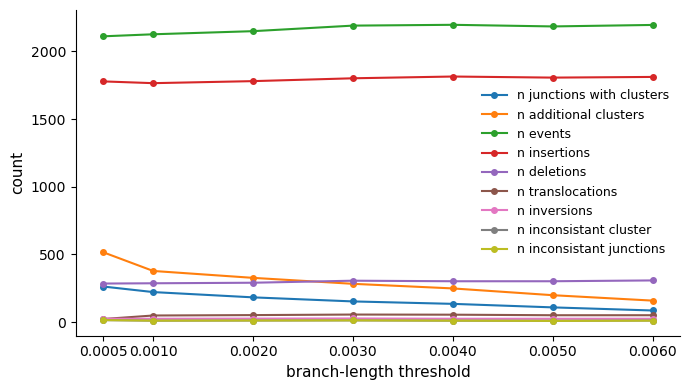

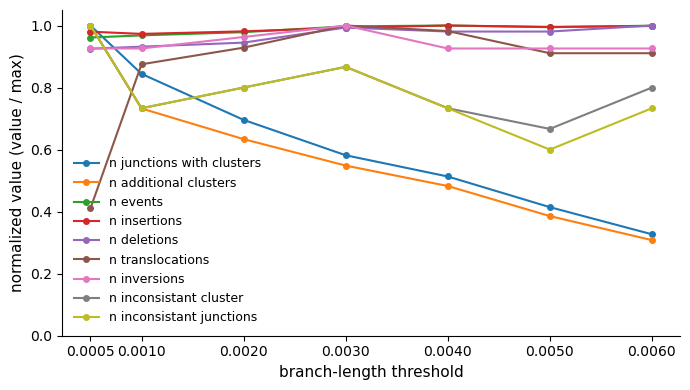

In [5]:
plot_clustering_threshold_sweep(results_df, figsize=(7,4), save_path=None, normalize=False)
plot_clustering_threshold_sweep(results_df, figsize=(7,4), save_path=None, normalize=True)

In [12]:
core_pairwise_paths = [f"../results/consensus_analysis/cluster_pairwise_dist_000{thresh}.csv" for thresh in [1,2,3,4,5,6]]
block_paths = [f"../results/consensus_analysis/cluster_block_ji_000{thresh}.csv" for thresh in [1,2,3,4,5,6]]
edge_paths = [f"../results/consensus_analysis/cluster_edge_ji_000{thresh}.csv" for thresh in [1,2,3,4,5,6]]

# maybe need to compare clustering between junctions that have clusters in all cases but more or less, this is done now
cluster_df = pd.read_csv(f"../results/consensus_analysis/cluster_maps_0_006.csv")
clustering_exists = cluster_df[cluster_df['n_clusters'] > 1].junction_name.to_list()

wb_core_pairwise_dfs = []
wb_block_dfs = []
wb_edge_dfs = []

for path in core_pairwise_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=False)
    wb_core_pairwise_dfs.append(wb_diff_df)

for path in block_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=True)
    wb_block_dfs.append(wb_diff_df)

for path in edge_paths:
    wb_diff_df = pd.read_csv(path)
    #wb_diff_df = wb_diff_df[wb_diff_df["n_clusters"] > 1]
    wb_diff_df = wb_diff_df[wb_diff_df["junction_name"].isin(clustering_exists)]
    wb_diff_df = add_silhouette_scores(wb_diff_df, within_col = 'mean_within_dist', between_col='mean_between_dist', is_similarity=True)
    wb_edge_dfs.append(wb_diff_df)

In [13]:
wb_block_dfs[0]

,junction_name,n_clusters,mean_between_dist,mean_within_dist,mean_within_dist_cl_0,mean_within_dist_cl_1,mean_within_dist_cl_2,mean_within_dist_cl_3,mean_within_dist_cl_4,mean_within_dist_cl_5,...,mean_between_dist_cl_3,mean_between_dist_cl_4,mean_between_dist_cl_5,mean_between_dist_cl_6,mean_between_dist_cl_7,mean_between_dist_cl_8,mean_between_dist_cl_9,mean_between_dist_cl_10,mean_between_dist_cl_11,silhouette_score
2,JNLRGIQXOF_f__YQUHGDANHE_f,3,0.998039,0.998028,0.996055,NaN,NaN,1.000000,NaN,NaN,...,0.998039,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.005772
16,JPYVXRYZLU_f__UUBXUCAQCF_f,2,0.998039,0.998039,0.996078,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
23,ITEMFVYTUE_r__JVDYVQZUBR_r,7,0.955426,0.990000,1.000000,NaN,NaN,NaN,NaN,1.00000,...,0.506335,NaN,0.504091,0.506335,NaN,0.965849,NaN,0.989486,0.987637,0.775655
24,ITEMFVYTUE_f__PIVHURLJVP_f,5,0.955886,0.999365,0.998095,NaN,NaN,NaN,NaN,1.00000,...,0.996833,NaN,0.996818,0.499548,0.996729,NaN,NaN,NaN,NaN,0.985607
25,ISADOQMCVR_r__JKXDSPORHF_r,4,0.974146,1.000000,1.000000,NaN,NaN,NaN,NaN,1.00000,...,0.998869,0.75,0.998832,NaN,NaN,NaN,NaN,NaN,NaN,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,VZOKOXMBEZ_r__YUOECYBHUS_f,9,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.000000,NaN,1.000000,1.000000,NaN,NaN,1.000000,0.000000
516,EVCCMUBHOL_r__WNLYKTZGKW_f,3,0.594506,0.978207,0.956413,1.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.946255
531,CYGJWOEQKN_r__EOBHADSLFU_r,2,0.946667,0.954286,1.000000,0.908571,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.142857
532,XXVMWZCEKI_r__YUOECYBHUS_r,12,0.577263,0.826530,0.706484,0.832499,NaN,0.968354,NaN,NaN,...,0.719649,NaN,0.703851,0.603329,NaN,0.476460,NaN,0.172605,0.219514,0.589651
